## 1. Read data

### 1.1. The dataset of sentences

In [3]:
import pandas as pd
sentence_df = pd.read_excel("/workspace/mijnidbcoachnlp/analysis_datasets/translated_sentence_data.xlsx")

In [4]:
sentences = sentence_df["Clean_Sentence"].to_list()

In [6]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('/workspace/mijnidbcoachnlp/analysis_datasets/stopwords.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

extra_list = [
    'maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag',
    'januari', 'februari', 'maart', 'april', 'mei', 'juni', 'juli', 'augustus', 'september', 'oktober', 'november', 'december',
    'jan', 'feb', 'mrt', 'apr', 'mei', 'jun', 'jul', 'aug', 'sep', 'okt', 'nov', 'dec'
]

dutch_stopwords.extend(extra_list)

## 2. Download the embedding model BERTje

In [7]:
from transformers.pipelines import pipeline
from transformers import AutoTokenizer, AutoModel, TFAutoModel
embedding_model = pipeline("feature-extraction", model="GroNLP/bert-base-dutch-cased")

Some weights of BertModel were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# pre-calculate the embeddings of the dutch sentences
import numpy as np

embeddings_nl = embedding_model(sentences, truncation=True, padding=True)
sentence_embeddings_nl = np.array([np.mean(embedding, axis=1).flatten() for embedding in embeddings_nl])

In [ ]:
# save the sentence embeddings
import numpy as np
np.save('/workspace/mijnidbcoachnlp/saved_models/sentence_embeddings_bertje_nl.npy', sentence_embeddings_nl)

In [7]:
# load the save model
import numpy as np

loaded_embeddings_nl = np.load('np.save('/workspace/mijnidbcoachnlp/saved_models/sentence_embeddings_bertje_nl.npy', sentence_embeddings_nl)
')

In [8]:
embeddings=loaded_embeddings_nl

## 3. Initial model 

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(embeddings)
cosine_dist = 1 - cosine_sim

# Step 2: Reduce dimensionality with UMAP
umap_model = UMAP(n_components=10, n_neighbors=10, metric='cosine', random_state=42)
umap_embeddings = umap_model.fit_transform(embeddings)

# Step 3: Run HDBSCAN with precomputed distances on UMAP-reduced embeddings
hdbscan_model = HDBSCAN(metric='precomputed', cluster_selection_method='eom', prediction_data=True)
cluster_labels = hdbscan_model.fit_predict(cosine_dist)

# Step 4: Set up BERTopic without passing `hdbscan_model`, and manually assign topics
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{2,}\b'),
    top_n_words=10,
    verbose=True
)

# Step 5: Assign the results from HDBSCAN manually
# Note: BERTopic expects a `fit_transform` to operate end-to-end
topics, probs = topic_model.fit_transform(sentences, umap_embeddings)

In [16]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,24652,-1_weken_laatste_gaan_klachten,"[weken, laatste, gaan, klachten, gaat, medicat...",[Ik krijg daarvan alleen diaree buikpijn was a...
1,0,225,0_omgaand reactie_adviseerde contact_graag van...,"[omgaand reactie, adviseerde contact, graag va...","[Daarom overleg ik graag vandaag nog (d.w.z., ..."
2,1,223,1_ziekenhuis_ziekenhuis ziekenhuis_apotheek zi...,"[ziekenhuis, ziekenhuis ziekenhuis, apotheek z...","[Het was in het [ZIEKENHUIS]., 8 januari moet ..."
3,2,178,2_afgesproken_afgesproken week_afgesproken afs...,"[afgesproken, afgesproken week, afgesproken af...",[Mijn vraag is: wat hadden we afgesproken te d...
4,3,163,3_krampen_buikpijn_misselijkheid_hoofdpijn,"[krampen, buikpijn, misselijkheid, hoofdpijn, ...",[Daarnaast blijf ik veel klachten van de colit...
...,...,...,...,...,...
1058,1057,5,1057_zojuist recept_apotheek nuth_recept zojui...,"[zojuist recept, apotheek nuth, recept zojuist...",[Het recept was zojuist om 16.55 nog niet binn...
1059,1058,5,1058_consequenties_invloed erop_vraag hoeverre...,"[consequenties, invloed erop, vraag hoeverre, ...",[Nu ontstaat er wel een verkeerd beeld van mij...
1060,1059,5,1059_nogmaals dank_nogmaals_goede zorg_dank he...,"[nogmaals dank, nogmaals, goede zorg, dank her...","[Nogmaals dank voor alles goede zorg!, Nogmaal..."
1061,1060,5,1060_aanleiding bloed_bekend spiegel_orde beke...,"[aanleiding bloed, bekend spiegel, orde bekend...",[lezer Is er al iets bekend over mijn Calpro ...


In [14]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,16667,-1_last_beter_nieuwe_klachten,"[last, beter, nieuwe, klachten, pijn, laatste,...",[Ik denk dat mijn buikklachten op dit moment e...
1,0,395,0_ziekenhuis_ziekenhuis ziekenhuis_apotheek zi...,"[ziekenhuis, ziekenhuis ziekenhuis, apotheek z...","[Ik kan naar [ZIEKENHUIS]., Beide bij het [ZIE..."
2,1,271,1_bekend uitslag_ontlasting bekend_ontlasting ...,"[bekend uitslag, ontlasting bekend, ontlasting...","[is de uitslag van de ontlasting al bekend?, i..."
3,2,188,2_afgesproken_coloscopie_afgesproken week_afge...,"[afgesproken, coloscopie, afgesproken week, af...",[Mijn vraag is: wat hadden we afgesproken te d...
4,3,146,3_afspraak afspraak_staan afspraak_afspraak st...,"[afspraak afspraak, staan afspraak, afspraak s...","[Ik heb in januari een afspraak met staan., D..."
...,...,...,...,...,...
1604,1603,5,1603_gevoel lucht_testen merk_daarbij buikpijn...,"[gevoel lucht, testen merk, daarbij buikpijn, ...","[Ik merk overigens ook dat de honger toeneemt,..."
1605,1604,5,1604_volgen arts_begrepen volgende_langer mail...,"[volgen arts, begrepen volgende, langer mail, ...",[Ik ben op 1 januari van zorgverzekering gewis...
1606,1605,5,1605_laboratorium formulieren_formulier nodig_...,"[laboratorium formulieren, formulier nodig, mo...",[Kunnen jullie mij dan het recept sturen voor ...
1607,1606,5,1606_terug consult_tegoed_onderzoeken coloscop...,"[terug consult, tegoed, onderzoeken coloscopie...","[Ik ben net positief getest op corona, ik heb ..."


## 3. Preparation for Fine-Tuning Hyperparameters

In [25]:
#generate a list of UMAP combinations
n_neighbors_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50] # we are aiming for strict clusters so the n_neighbors range is relatively small
n_components_values = [2, 3, 4, 5, 6, 7]

#generate a list of HDBSCAN combinations
min_cluster_size_values = [2, 3, 5, 8, 10, 15, 20, 30]
min_samples_values = [5, 10, 15, 20, 35, 50]

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_intra_topic_cosine_similarity(embeddings, topics):
    topic_similarities = []
    
    for topic in set(topics):
        if topic == -1:  # Skip the "outlier" topic
            continue
        
        # Get embeddings of documents in the current topic
        topic_embeddings = embeddings[np.array(topics) == topic]
        
        if len(topic_embeddings) < 2:
            continue  # Skip topics with a single document
        
        # Calculate cosine similarities and average them
        cosine_sim = cosine_similarity(topic_embeddings)
        avg_cosine_sim = cosine_sim[np.triu_indices_from(cosine_sim, k=1)].mean()
        
        topic_similarities.append(avg_cosine_sim)

    return topic_similarities

## 4. Model 3: BERTje + UMAP + HDBSCAN

### 4.1 Fine-Tuning UMAP hyper parameters

#### 4.1.1 Fine-tuning n_neighbors

In [10]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import numpy as np

model_topic_similarities_nneighbors = []  # Initialize as a list to store each model's results

for n_neighbors in n_neighbors_values:

    
    topic_model = BERTopic(
        # Pipeline models
        embedding_model=embedding_model,
        umap_model=UMAP(n_neighbors=n_neighbors, metric='cosine', random_state=42),
        hdbscan_model=HDBSCAN(metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{2,}\b'),

        # Hyperparameters
        nr_topics=100,
        top_n_words=10,
        verbose=True
    )

    # Train model
    topics, probs = topic_model.fit_transform(sentences, embeddings)
    topics = topic_model.get_document_info(sentences)["Topic"]
    
    # Compute intra-topic cosine similarity
    intra_topic_similarity = calculate_intra_topic_cosine_similarity(embeddings, topics)
    

    model_topic_similarities_nneighbors.append(intra_topic_similarity)

model_topic_similarities_nneighbors

2024-10-31 14:16:48,823 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 14:18:06,058 - BERTopic - Dimensionality - Completed ✓
2024-10-31 14:18:06,059 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 14:18:11,154 - BERTopic - Cluster - Completed ✓
2024-10-31 14:18:11,170 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-10-31 14:18:12,899 - BERTopic - Representation - Completed ✓
2024-10-31 14:18:12,903 - BERTopic - Topic reduction - Reducing number of topics
2024-10-31 14:18:14,530 - BERTopic - Topic reduction - Reduced number of topics from 1731 to 100
2024-10-31 14:18:44,705 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 14:19:20,241 - BERTopic - Dimensionality - Completed ✓
2024-10-31 14:19:20,250 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 14:19:22,207 - BERTopic - Cluster - Completed ✓
2024-10-31 14:1

[[0.750706574034529,
  0.7982394057690357,
  0.7639312393023725,
  0.7028028590424356,
  0.8097265742803359,
  0.8559501156999364,
  0.8419971771193066,
  0.7592653139110613,
  0.9120266271762606,
  0.7933454357779873,
  0.8188240993034701,
  0.7512271794437976,
  0.7504946306343389,
  0.7557845129721853,
  0.9345493371156559,
  0.738702932424232,
  0.8576983262576489,
  0.7653953872961528,
  0.7326794302661783,
  0.8586446842516782,
  0.7698658166596515,
  0.8195424137723885,
  0.7234211875629829,
  0.7907006007888212,
  0.8548182198476908,
  0.7083956217032829,
  0.7766632422513332,
  0.8222251419885416,
  0.7711230224013771,
  0.79657197611312,
  0.8597360282391764,
  0.7857971420338142,
  0.8229271604887876,
  0.7803873610755002,
  0.841307434071336,
  0.8268239809876886,
  0.8362038241727715,
  0.7637113538374125,
  0.9818203096515616,
  0.7371094706858549,
  0.8277671923694201,
  0.7244408572423805,
  0.9706808979822689,
  0.7806044952091337,
  0.7837266397589635,
  0.90317142148

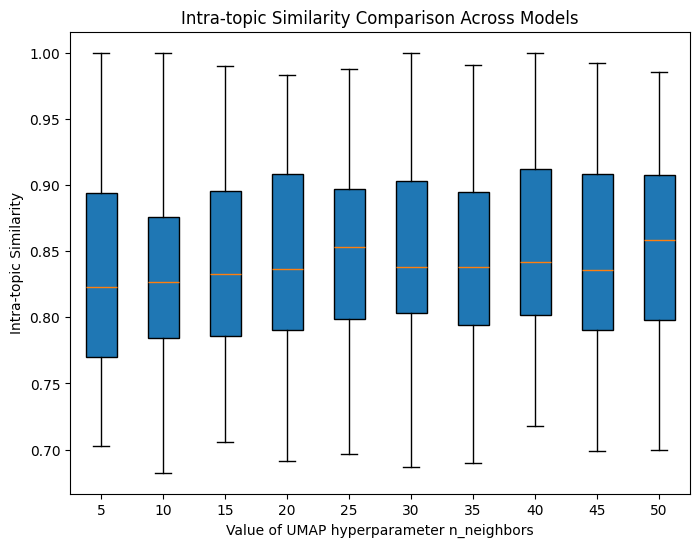

In [11]:
# Print the results
# Prepare data for plotting
data = model_topic_similarities_nneighbors

# Customizing the plot
# Plot boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(data, patch_artist=True)
plt.xticks(range(1, len(data) + 1), n_neighbors_values)  # Dynamically set labels
plt.xlabel("Value of UMAP hyperparameter n_neighbors")
plt.ylabel("Intra-topic Similarity")
plt.title("Intra-topic Similarity Comparison Across Models")
plt.show()

#### 4.1.2. Fine-tuning n-components

In [12]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import numpy as np

model_topic_similarities_ncomponents = []  # Initialize as a list to store each model's results

for n_components in n_components_values:

    
    topic_model = BERTopic(
        # Pipeline models
        embedding_model=embedding_model,
        umap_model=UMAP(n_neighbors=25, n_components=n_components, metric='cosine', random_state=42),
        hdbscan_model=HDBSCAN(metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{2,}\b'),

        # Hyperparameters
        nr_topics=100,
        top_n_words=10,
        verbose=True
    )

    # Train model
    topics, probs = topic_model.fit_transform(sentences, embeddings)
    topics = topic_model.get_document_info(sentences)["Topic"]
    
    # Compute intra-topic cosine similarity
    intra_topic_similarity = calculate_intra_topic_cosine_similarity(embeddings, topics)
    

    model_topic_similarities_ncomponents.append(intra_topic_similarity)


2024-10-31 14:52:58,852 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 14:53:45,248 - BERTopic - Dimensionality - Completed ✓
2024-10-31 14:53:45,249 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 14:53:49,226 - BERTopic - Cluster - Completed ✓
2024-10-31 14:53:49,227 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-10-31 14:53:50,446 - BERTopic - Representation - Completed ✓
2024-10-31 14:53:50,455 - BERTopic - Topic reduction - Reducing number of topics
2024-10-31 14:53:51,242 - BERTopic - Topic reduction - Reduced number of topics from 1592 to 100
2024-10-31 14:54:04,623 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 14:54:50,016 - BERTopic - Dimensionality - Completed ✓
2024-10-31 14:54:50,018 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 14:54:51,606 - BERTopic - Cluster - Completed ✓
2024-10-31 14:5

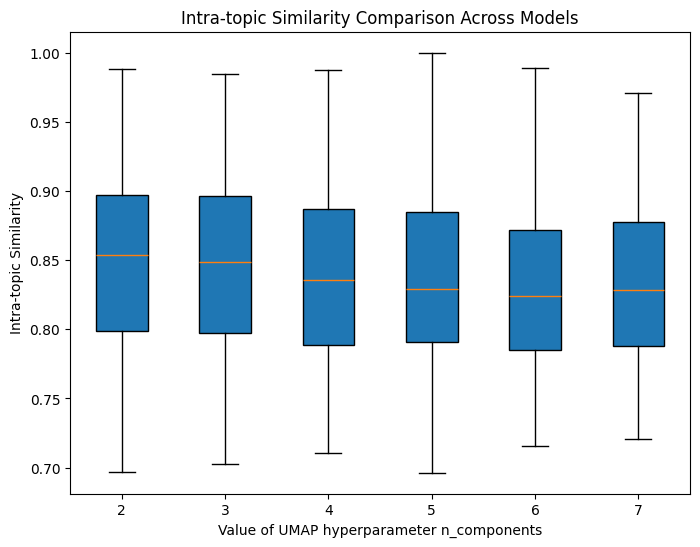

In [13]:
# Print the results
# Prepare data for plotting
data = model_topic_similarities_ncomponents

# Customizing the plot
# Plot boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(data, patch_artist=True)
plt.xticks(range(1, len(data) + 1), n_components_values)  # Dynamically set labels
plt.xlabel("Value of UMAP hyperparameter n_components")
plt.ylabel("Intra-topic Similarity")
plt.title("Intra-topic Similarity Comparison Across Models")
plt.show()

#### 4.1.3. Fine-tuning min_cluster_size

In [22]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import numpy as np

model_topic_similarities_minclustersize = []  # Initialize as a list to store each model's results

for min_cluster_size in min_cluster_size_values:

    
    topic_model = BERTopic(
        # Pipeline models
        embedding_model=embedding_model,
        umap_model=UMAP(n_neighbors=25, n_components=2, metric='cosine', random_state=42),
        hdbscan_model=HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{2,}\b'),

        # Hyperparameters
        nr_topics=100,
        top_n_words=10,
        verbose=True
    )

    # Train model
    topics, probs = topic_model.fit_transform(sentences, embeddings)
    topics = topic_model.get_document_info(sentences)["Topic"]
    
    # Compute intra-topic cosine similarity
    intra_topic_similarity = calculate_intra_topic_cosine_similarity(embeddings, topics)
    

    model_topic_similarities_minclustersize.append(intra_topic_similarity)


2024-10-31 16:09:41,887 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 16:11:16,198 - BERTopic - Dimensionality - Completed ✓
2024-10-31 16:11:16,206 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 16:11:28,316 - BERTopic - Cluster - Completed ✓
2024-10-31 16:11:28,316 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-10-31 16:11:33,631 - BERTopic - Representation - Completed ✓
2024-10-31 16:11:33,639 - BERTopic - Topic reduction - Reducing number of topics
2024-10-31 16:11:39,501 - BERTopic - Topic reduction - Reduced number of topics from 6319 to 100
2024-10-31 16:13:09,640 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-31 16:14:34,343 - BERTopic - Dimensionality - Completed ✓
2024-10-31 16:14:34,348 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-31 16:14:39,568 - BERTopic - Cluster - Completed ✓
2024-10-31 16:1

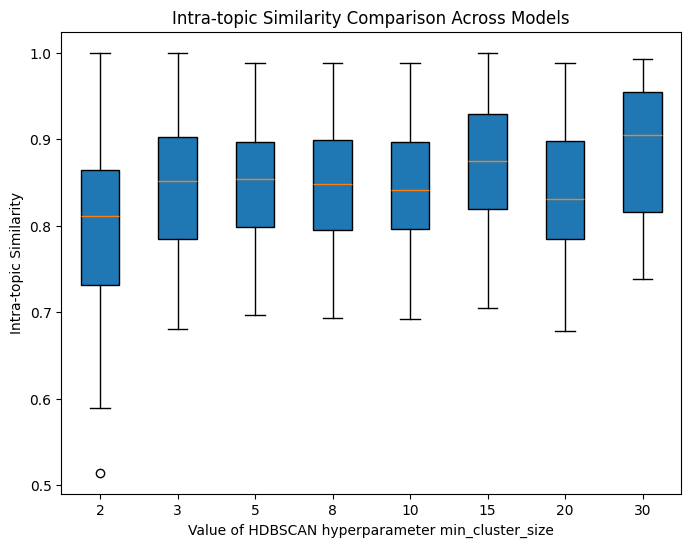

In [27]:
# Print the results
# Prepare data for plotting
data = model_topic_similarities_minclustersize
# Customizing the plot
# Plot boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(data, patch_artist=True)
plt.xticks(range(1, len(data) + 1), min_cluster_size_values)  # Dynamically set labels
plt.xlabel("Value of HDBSCAN hyperparameter min_cluster_size")
plt.ylabel("Intra-topic Similarity")
plt.title("Intra-topic Similarity Comparison Across Models")
plt.show()

## 5. Model 4 Bertje + KMeans

In [49]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.cluster import KMeans
topic_model_2 = BERTopic(

  # Pipeline models
  embedding_model=embedding_model,
  umap_model=UMAP(n_neighbors=10, n_components=5, metric='cosine', random_state=42),
  #umap_model=UMAP(n_neighbors=20, n_components=2, min_dist=0.0, metric='cosine', random_state=42),
  hdbscan_model = KMeans(n_clusters=200),
  vectorizer_model = CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{2,}\b'),

  # Hyperparameters
  top_n_words=10,
  verbose=True
)

# Train model
topics_2, probs_2 = topic_model_2.fit_transform(sentences, embeddings)

2024-10-30 13:33:06,590 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-10-30 13:33:34,184 - BERTopic - Dimensionality - Completed ✓
2024-10-30 13:33:34,184 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-10-30 13:33:35,367 - BERTopic - Cluster - Completed ✓
2024-10-30 13:33:35,381 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-10-30 13:33:35,949 - BERTopic - Representation - Completed ✓


C:\Users\p70092940\AppData\Local\Temp\ipykernel_35100\1085735622.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(topics))(np.arange(len(topics)))


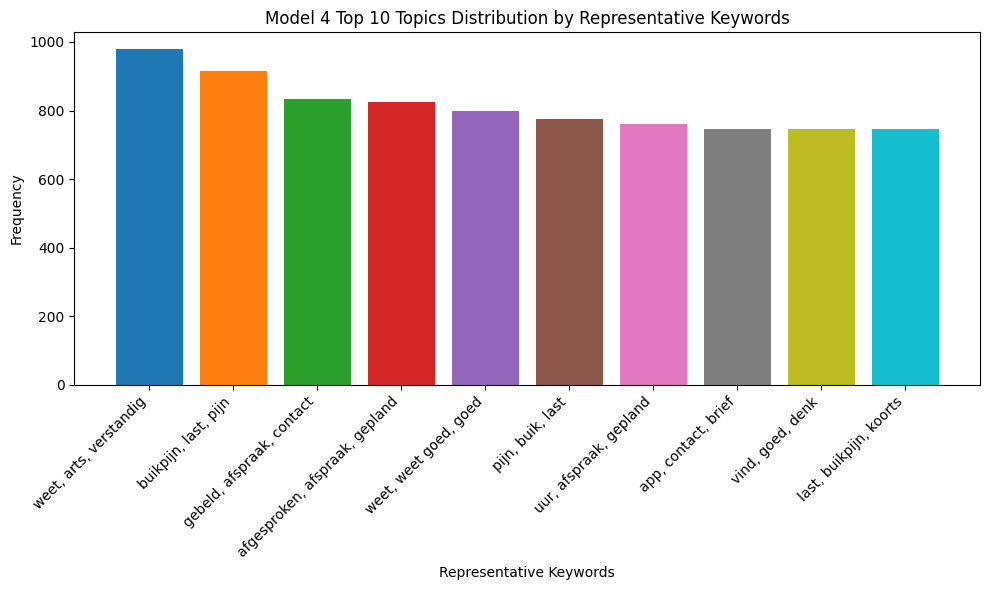

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Get the top 10 topics and their frequencies
freq_df = topic_model_2.get_topic_freq().head(10)  # Get the top 10 topics
topics = freq_df['Topic'].values
frequencies = freq_df['Count'].values

# Extract the representative keywords for each topic
topic_labels = []
for topic in topics:
    if topic != -1:  # Skip -1, which is usually the "outlier" topic
        words = [word for word, _ in topic_model_2.get_topic(topic)]
        topic_labels.append(", ".join(words[:3]))  # Join the top 3 words for each topic as a label
    else:
        topic_labels.append("Outlier")  # Label for outliers if they exist

# Generate a color map with unique colors for each bar
colors = cm.get_cmap("tab10", len(topics))(np.arange(len(topics)))

# Plot
plt.figure(figsize=(10, 6))
plt.bar(topic_labels, frequencies, color=colors)
plt.xlabel("Representative Keywords")
plt.ylabel("Frequency")
plt.title("Model 4 Top 10 Topics Distribution by Representative Keywords")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
topic_info_2 = topic_model_2.get_topic_info()
pd.set_option("display.max_colwidth", 300)
topic_info_2[:11]

,Topic,Count,Name,Representation,Representative_Docs
0,0,923,0_buikpijn_last_pijn_buik,"[buikpijn, last, pijn, buik, gevoel, diarree, nacht, toilet, wc, eten]","[Heb er nu weer veel last van maar dat is met tijd en wijle., In het begin kreeg ik vooral pijn in mijn buik als ik iets aan het eten of drinken was., Ik heb wel af en toe wat last van mijn buik, dat ik gelijk naar het toilet moet.]"
1,1,839,1_app_foto_meld_brief,"[app, foto, meld, brief, telefoon, vragen, arts, contact, weet, invullen]","[Ik heb ook geprobeerd om een foto van de brief mee te sturen in d'r app., Ik heb geprobeerd de app op mijn telefoon te openen, maar hij zegt dat mijn telefoon (samsung A71) deze app niet ondersteunt., Ik kom niet weg met de test via de app.]"
2,2,835,2_pijn_last_buikpijn_buik,"[pijn, last, buikpijn, buik, gevoel, krampen, rug, onderbuik, diarree, steken]","[alleen een stekende pijn in de rechter onderbuik maar dat heb ik al lang, Wel nog buikpijn., Verder last van jeugdpuistjes, zonder dat ik hier voorheen last van had.]"
3,3,827,3_afgesproken_afspraak_gepland_coloscopie,"[afgesproken, afspraak, gepland, coloscopie, endoscopie, poli, gemaakt, week, vakantie, afspraak gemaakt]","[Ik moet inderdaad wel mijn ontlasting inleveren, dit had ik met haar afgesproken., Mijn vraag is: wat hadden we afgesproken te doen na dit infuus?, Wil jij het zoals afgesproken daar naar toe sturen?]"
4,4,820,4_weet_vind_begrijp_goed,"[weet, vind, begrijp, goed, vraag, vragen, denk, arts, probleem, gezien]","[Ik heb hiermee de huisarts gebeld omdat ik het akelig vind en door de pijn niet goed meer naar het toilet durf maar de assistente zei dat ik hiermee naar de mdl arts moest gaan., Ik weet niet of dit precies hetzelfde is, volgens hun wel., Ik heb hiermee de huisarts gebeld omdat ik het akelig vi..."
5,5,781,5_mogelijk_telefonisch_opgestuurd_bellen,"[mogelijk, telefonisch, opgestuurd, bellen, afspraak, ophalen, hiervoor, mogelijk afspraak, huisarts, telefonisch contact]","[Is het mogelijk om een afspraak bij in te plannen?, Is t mogelijk om als nog telefonisch contact te hebben met ?, Is het mogelijk dat ik er een opgestuurd krijg?]"
6,6,772,6_prikken_laten prikken_inleveren_ontlasting inleveren,"[prikken, laten prikken, inleveren, ontlasting inleveren, bloed laten, laten, infuus, bloed, spuit, ontlasting]","[Ik wil volgende week bloed prikken en ontlasting doen en 6 juli als ik opnieuw moet spuiten doe ik de spiegel laten prikken, Normalerwijs moest ik vtv bloed prikken of ontlasting inleveren., Ik zal deze week bloed laten prikken en ontlasting inleveren.]"
7,7,768,7_toilet_ontlasting_dag_keer,"[toilet, ontlasting, dag, keer, wc, keer dag, slijm, soms, vaker, dag toilet]","[Ik moet nog steeds 8 tot 10 keer per dag naar toilet en dan nog steeds slijm met vers bloedverlies en waterige ontlasting., Ook hoef ik nu maar een enkele keer per dag naar t toilet., Dit is zo 4a5 keer per dag.]"
8,8,763,8_gebeld_contact_afspraak_poli,"[gebeld, contact, afspraak, poli, ontvangen, telefonisch, bellen, opnemen, huisarts, gestuurd]","[Echter kwam ik zojuist bij de apotheek en hebben zij geen recept ontvangen., Ze hebben contact gehad met en daar zijn ze wel., Heb vanmorgen mijn huisarts gebeld en die zei dat ik contact met jullie moest opnemen.]"
9,9,740,9_last_buikpijn_koorts_darmen,"[last, buikpijn, koorts, darmen, last darmen, moe, weken last, laatste, dagen, weken]","[Heb er nog steeds last van., Ja ik had inderdaad wat meer last., Nergens last van.]"


In [50]:
doc_info_2 = topic_model_2.get_document_info(sentences)
pd.set_option("display.max_colwidth", 300)
doc_info_2[["Document", "Topic", "Name"]].iloc[269:276]

,Document,Topic,Name
269,het gaat weer iets beter en ik heb gisteren de test proberen te doen.,73,73_test_test gedaan_gedaan_quanton
270,Het liep goed totdat ik probeerde de onderkant van het buisje te breken.,78,78_vloeistof_aambeien_cm_darm
271,Ik kreeg het niet voor elkaar en heb toen meer kracht gebruikt.,40,40_echt_gaat_goed gaat_voel
272,j lijkt me nu op de verkeerde plek gebroken (zie foto).,69,69_weet_verkeerd_vraag gesteld_gesteld
273,De test is uiteindelijk mislukt volgens de app.,52,52_app_telefoon_downloaden_foto
274,Waar moet het buisje breken en hoe krijg ik dit het beste voor elkaar?,34,34_geregeld_mogelijk_rekening_mogelijkheid
275,Kan ik nog een of twee nieuwe testen krijgen?,22,22_recept krijgen_mogelijk_krijgen_opgestuurd


In [ ]:
# calculate some metrics
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

topics = topic_model_2.get_document_info(sentences)["Topic"]  # Document-topic assignments

def calculate_intra_topic_cosine_similarity(embeddings, topics):
    topic_similarities = {}
    
    for topic in set(topics):
        if topic == -1:  # Skip the "outlier" topic
            continue
        
        # Get embeddings of documents in the current topic
        topic_embeddings = embeddings[np.array(topics) == topic]
        
        if len(topic_embeddings) < 2:
            continue  # Skip topics with a single document
        
        # Calculate cosine similarities and average them
        cosine_sim = cosine_similarity(topic_embeddings)
        avg_cosine_sim = cosine_sim[np.triu_indices_from(cosine_sim, k=1)].mean()
        
        topic_similarities[topic] = avg_cosine_sim

    return topic_similarities

# Compute intra-topic cosine similarity
intra_topic_similarity = calculate_intra_topic_cosine_similarity(embeddings, topics)
print(intra_topic_similarity)


# Generate `X` and `labels` only for non-outlier topics (as they are technically not clusters)
umap_embeddings = topic_model_2.umap_model.transform(embeddings)
indices = [index for index, topic in enumerate(topics) if topic != -1]
X = umap_embeddings[np.array(indices)]
labels = [topic for index, topic in enumerate(topics) if topic != -1]


{0: 0.8252693719052538, 1: 0.7852547315959064, 2: 0.762862893497315, 3: 0.820879940349825, 4: 0.8017023271356827, 5: 0.8108400741770095, 6: 0.8330059012523281, 7: 0.791123173249664, 8: 0.8180030150819796, 9: 0.8285181283951095, 10: 0.7620362331737945, 11: 0.8254971798179783, 12: 0.8215087708184208, 13: 0.8341168477095273, 14: 0.8009109919585566, 15: 0.7778740580620145, 16: 0.8163820277763174, 17: 0.7924064106286378, 18: 0.7914533085247405, 19: 0.8174125133595446, 20: 0.8195069566039965, 21: 0.7999406906245679, 22: 0.815438783053087, 23: 0.8175989232400881, 24: 0.7994843339619994, 25: 0.7722410497374249, 26: 0.8204036482268204, 27: 0.7445295834301378, 28: 0.8037165451274363, 29: 0.8150697419189922, 30: 0.7955681164585469, 31: 0.8083881725259724, 32: 0.8099515177011445, 33: 0.8202904216825992, 34: 0.7863328679043089, 35: 0.7908318327469491, 36: 0.821398482236987, 37: 0.833673301580741, 38: 0.8302440054944598, 39: 0.7706513248627224, 40: 0.7536506377679552, 41: 0.7859859609511187, 42: 0.7

0.29391637

In [12]:
hierarchical_topics_2 = topic_model_2.hierarchical_topics(sentences)
topic_model_2.visualize_hierarchy(hierarchical_topics=hierarchical_topics_2)


100%|██████████| 99/99 [00:00<00:00, 376.58it/s]
